# Qwen3Guard-Stream: потоковый baseline

Ноутбук запускает один токенный проход Qwen3Guard для каждой трассы, сохраняет его и затем воспроизводит шесть режимов буферизации с двумя политиками безопасности. Логика эксперимента импортируется из Python-пакета; полные чувствительные запросы и ответы не выводятся.

## 1. Конфигурация

`smoke` выбирает 5 безопасных и 5 опасных трасс. `full` использует все 500. Для локальной проверки без NVIDIA можно заменить `cuda` на `cpu`, но показатели времени после этого нельзя напрямую сравнивать с запуском на видеокарте.

In [ ]:
import platform
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch

from streamguard_bench.experiments import (
    load_boundary_dataset,
    load_experiment_run,
    run_experiment,
    select_profile_traces,
)
from streamguard_bench.guards import Qwen3GuardStreamAdapter
from streamguard_bench.metrics import compute_streaming_metrics

PROFILE = "full"  # "smoke" или "full"
RUN_MODEL = False  # False читает готовые файлы, True запускает Qwen3Guard
DEVICE = "mps" if torch.backends.mps.is_available() else "cpu"
RESUME = True
SEED = 42
DATASET_REVISION = "c36ddf315be89916c64fd6eb3b5a00ea6d505d1a"
MODEL_REVISION = "419364a715de9840d47b1457982f64ff37f90ed4"

MODES = ["token", "chunk_8", "chunk_16", "chunk_32", "sentence", "full_buffered"]
POLICIES = ["strict", "conservative"]
ROOT = Path.cwd() if (Path.cwd() / "pyproject.toml").exists() else Path.cwd().parent
OUTPUT_DIR = ROOT / "data/interim/qwen3guard_baseline"

## 2. Окружение

Эти сведения нужны для воспроизводимости задержки. Версии модели и токенизатора дополнительно сохраняются рядом с результатами.

In [2]:
environment = {
    "profile": PROFILE,
    "device": DEVICE,
    "python": platform.python_version(),
    "platform": platform.platform(),
    "output_dir": str(OUTPUT_DIR),
}
pd.Series(environment, name="value")

profile                                                    full
device                                                      mps
python                                                  3.12.14
platform                           macOS-15.6.1-arm64-arm-64bit
output_dir    /Users/anastasia/Streaming-Guardrails/data/int...
Name: value, dtype: str

## 3. Загрузка и выбор трасс

Показываются только идентификаторы, итоговые метки и категории. Текст запросов и ответов остаётся внутри объекта данных.

In [3]:
if RUN_MODEL:
    dataset = load_boundary_dataset(
        revision=DATASET_REVISION,
        cache_dir=ROOT / "data/cache/huggingface",
    )
    selected = select_profile_traces(dataset, PROFILE, seed=SEED)
    print(f"Выбрано трасс: {len(selected)}")
    display(selected[["trace_id", "source_split", "label", "harm_categories"]])
else:
    dataset = None
    print("Датасет не загружается: используем сохранённый результат.")

/Users/anastasia/Streaming-Guardrails/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Выбрано трасс: 500


,trace_id,source_split,label,harm_categories
0,01496c9f9bd5353cdb6e,train,unsafe,"[Non-violent Illegal Acts, Personally Identifi..."
1,01d9b93e3ab6beada067,train,unsafe,"[Personally Identifiable Information, Unethica..."
2,03112c4130e4b640021c,train,unsafe,"[Non-violent Illegal Acts, Politically Sensiti..."
3,052d9264584ffb0ec8fa,train,safe,[]
4,0567d8ef4b5d7a96f439,train,unsafe,"[Non-violent Illegal Acts, Unethical Acts]"
...,...,...,...,...
495,fee24627b1416bd79070,train,unsafe,"[Non-violent Illegal Acts, Personally Identifi..."
496,ff06b88e4dc6c6738d7a,train,unsafe,"[Non-violent Illegal Acts, Copyright Violation]"
497,ff5de963621a43dd2912,val,unsafe,[Non-violent Illegal Acts]
498,ff6f3119716d9a2076ce,train,unsafe,"[Non-violent Illegal Acts, Unethical Acts, Pol..."


## 4. Загрузка Qwen3Guard

Загружается модель `Qwen/Qwen3Guard-Stream-0.6B`. Она не обучается: используются опубликованные веса.

In [4]:
if RUN_MODEL:
    guard = Qwen3GuardStreamAdapter(
        "Qwen/Qwen3Guard-Stream-0.6B",
        revision=MODEL_REVISION,
        tokenizer_revision=MODEL_REVISION,
        device=DEVICE,
    )
    print({
        "model": guard.model_id,
        "model_revision": guard.model_revision,
        "tokenizer_revision": guard.tokenizer_revision,
        "device": guard.device,
    })
else:
    guard = None
    print("Модель не загружается: используем сохранённый результат.")

`torch_dtype` is deprecated! Use `dtype` instead!


{'model': 'Qwen/Qwen3Guard-Stream-0.6B', 'model_revision': '419364a715de9840d47b1457982f64ff37f90ed4', 'tokenizer_revision': '419364a715de9840d47b1457982f64ff37f90ed4', 'device': 'mps'}


## 5. Запуск или продолжение

После каждой трассы токенные решения сохраняются в `data/interim`. При повторном запуске с `RESUME = True` завершённые трассы не вычисляются заново.

In [7]:
if RUN_MODEL:
    run = run_experiment(
        dataset=dataset,
        guard=guard,
        profile=PROFILE,
        modes=MODES,
        policies=POLICIES,
        output_dir=OUTPUT_DIR,
        resume=RESUME,
        seed=SEED,
        dataset_revision=DATASET_REVISION,
    )
else:
    run = load_experiment_run(OUTPUT_DIR, profile=PROFILE)
print(f"Результаты: {run.output_dir}")
print(f"Трасс: {len(run.selected_trace_ids)}; токенных решений: {len(run.token_decisions)}")

Результаты: /Users/anastasia/Streaming-Guardrails/data/interim/qwen3guard_baseline/full
Трасс: 500; токенных решений: 53980


## 6. Проверка полноты

Для `smoke` ожидается 120 строк, для `full` — 6000. Ошибка одной трассы представлена во всех 12 комбинациях, поэтому её нельзя незаметно принять за безопасный результат.

In [8]:
expected_traces = 10 if PROFILE == "smoke" else 500
expected_rows = expected_traces * len(MODES) * len(POLICIES)
assert len(run.results) == expected_rows, (len(run.results), expected_rows)
assert run.results[["trace_id", "mode", "policy"]].duplicated().sum() == 0
print(f"Строк: {len(run.results)} из {expected_rows}; ошибок трасс: {len(run.errors)}")
display(run.errors)

Строк: 6000 из 6000; ошибок трасс: 0


,trace_id,error_type,error


## 7. Как работают режимы и политики

Qwen3Guard получает токены **ответа модели** последовательно и сохраняет накопленный контекст: при проверке нового токена модель учитывает весь уже обработанный префикс. Режим определяет не контекст Qwen3Guard, а размер текста, который приложение удерживает скрытым перед показом пользователю.

### Режимы проверки

- **`token`** — каждый новый токен удерживается до решения Qwen3Guard. Если метка разрешена политикой, токен показывается; если запрещена — генерация блокируется до его показа.
- **`chunk_8`, `chunk_16`, `chunk_32`** — приложение скрыто накапливает соответственно 8, 16 или 32 новых токена. Например, в `chunk_16` сначала проверяются токены 1–16: если среди их решений нет блокирующей метки, весь фрагмент показывается; затем так же обрабатываются токены 17–32. Предыдущий фрагмент не входит в новый буфер показа, но Qwen3Guard его **не забывает** и продолжает учитывать весь префикс. Если внутри текущего чанка появился блокирующий сигнал, весь ещё не показанный чанк блокируется.
- **`sentence`** — текст удерживается до конца предложения и затем показывается либо блокируется целиком. Если знаков конца предложения долго нет, проверка принудительно завершается после 128 токенов.
- **`full_buffered`** — весь ответ остаётся скрытым до завершения генерации. Qwen3Guard по-прежнему оценивает его токен за токеном с накопленным контекстом; если блокирующий сигнал появился хотя бы один раз, пользователю не показывается весь ответ.

### Политики обработки меток

Qwen3Guard возвращает три класса: `Safe` — безопасно, `Controversial` — спорно или недостаточно уверенности, `Unsafe` — небезопасно.

- **`strict`** — блокирует только `Unsafe`; `Safe` и `Controversial` разрешает.
- **`conservative`** — блокирует `Unsafe` и `Controversial`; разрешает только `Safe`. Такая политика обычно раньше останавливает возможный вред, но может чаще блокировать безопасные ответы.

> **Важно:** результаты по 10 трассам проверяют работоспособность конвейера. Они не являются статистической оценкой качества Qwen3Guard. Исследовательские выводы можно делать только после профиля `full`.

In [ ]:
metrics = compute_streaming_metrics(
    run.results,
    group_by=["mode", "policy"],
)
classification_summary = (
    metrics.groupby("policy", as_index=False)[
        ["false_positives", "false_positive_rate", "false_negatives", "false_negative_rate"]
    ]
    .first()
)
display(classification_summary)

## 8. Ошибки классификации: сравниваются политики, а не режимы

- **False Positive Rate (FPR), доля ложных блокировок** — доля безопасных ответов, которые система ошибочно заблокировала.
- **False Negative Rate (FNR), доля пропусков** — доля опасных ответов, которые система не заблокировала.

Все шесть режимов используют одну и ту же сохранённую последовательность токенных решений Qwen3Guard. Поэтому внутри одной политики значения FPR и FNR у `token`, чанков, `sentence` и `full_buffered` одинаковы. Режим меняет только момент вмешательства и количество уже показанных токенов.

Различие есть только между политиками: `strict` блокирует `Unsafe`, а `conservative` — `Unsafe` и `Controversial`. В полном прогоне `strict` дал FPR 13,2% и FNR 1,6%; `conservative` — FPR 14,0% и FNR 1,6%. Поэтому повторяющийся график по режимам заменён компактной таблицей политик. Полные чувствительные ответы не отображаются.

### Итог по политикам

| Политика | Ложные блокировки | FPR | Пропуски опасных ответов | FNR |
|---|---:|---:|---:|---:|
| `strict` | 33 из 250 | 13,2% | 4 из 250 | 1,6% |
| `conservative` | 35 из 250 | 14,0% | 4 из 250 | 1,6% |

Повторение этих значений для каждого режима не является отдельным результатом: буферизация не изменяет классификацию.

![Ошибки классификации по политикам](../reports/figures/qwen3guard_policy_errors.png)

## 9. Ошибки без чувствительного текста

In [11]:
if run.errors.empty:
    print("Все выбранные трассы обработаны успешно.")
else:
    display(run.errors[["trace_id", "error_type", "error"]])

Все выбранные трассы обработаны успешно.


## 10. Интерпретация результатов

Здесь важно различать четыре момента:

- `signal_token` — первый токен, на котором Qwen3Guard выдал блокирующую метку;
- `intervention_token` — граница, на которой политика буферизации реально применила блокировку;
- `released_tokens` — сколько токенов ответа уже было показано пользователю до блокировки;
- интервал начала вреда `[L, U)` — вред мог начаться после `L`, но к `U` уже подтверждён первым префиксом `unsafe`.

Утечка измеряет уже **показанный опасный текст**: нижняя оценка использует позднюю границу `U`, верхняя — раннюю `L`. Задержка вмешательства измеряет число сгенерированных токенов от возможного начала вреда до блокировки. Это не время ожидания одного токена в интерфейсе и не задержка в миллисекундах.

В режиме `token` дополнительное ожидание после сигнала равно нулю, но сам сигнал может появиться только после нескольких токенов ответа. В `chunk_8` блокировка применяется в конце чанка, содержащего сигнал; в `chunk_16` и `chunk_32` — аналогично. Поэтому общая задержка не обязана равняться 1, 8, 16 или 32: она включает путь от границы вреда до сигнала модели, остаток текущего чанка, последний неполный чанк и неопределённость интервала `[L, U)`.

В текущих 250 опасных трассах `L = 0`: до первого опасного префикса нет более короткого надёжно размеченного безопасного префикса. Поэтому верхняя оценка очень консервативна — она считает, что вред мог начаться с самого начала ответа.

Метрики по всем 500 трассам не используются для анализа `released_tokens`: безопасные ответы обычно показываются полностью и поднимают среднее примерно до 53 токенов. Для анализа утечки ниже оставлены только 250 опасных трасс.

leakage считается от точки release (сколько отдали пользователю), а detection_delay —
от точки intervention относительно начала вреда (onset). Это две разные вещи, и стоит
смотреть на них рядом, а не по отдельности — иначе легко решить, что режим с меньшим
leakage "безопаснее", хотя он может медленнее реагировать на уже начавшийся вред.

Ниже метрики пересчитываются на опасных трассах. Это отделяет объём текста, показанного до блокировки, от длины полностью показанных безопасных ответов.

In [ ]:
unsafe_results = run.results[run.results["ground_truth_label"] == "unsafe"]
metrics_unsafe = compute_streaming_metrics(unsafe_results, group_by=["mode", "policy"])
streaming_summary = metrics_unsafe[metrics_unsafe["policy"] == "strict"][
    [
        "mode",
        "released_tokens_mean",
        "leakage_min_mean",
        "leakage_max_mean",
        "signal_token_mean",
        "intervention_token_mean",
    ]
].copy()
streaming_summary["post_signal_buffer_delay_mean"] = (
    streaming_summary["intervention_token_mean"] - streaming_summary["signal_token_mean"]
)
display(streaming_summary.round(2))

Метрики ниже пересчитаны только на опасных трассах. В общей таблице `released_tokens` усредняется вместе с безопасными ответами, которые обычно показываются полностью, поэтому среднее около 53 токенов не характеризует утечку.

На опасных трассах режим `token` показывает в среднем 4,46 токена **от начала ответа** до блокировки. Это не означает, что четыре токена заведомо опасны: из-за интервала `[0, U)` точное начало вреда неизвестно. Чанки показывают меньше токенов не потому, что лучше распознают опасность, а потому, что целиком удерживают текущий чанк, в котором уже появился сигнал.

| Режим | Показано до блокировки | Возможная утечка | Вмешательство | Дополнительное ожидание после сигнала |
|---|---:|---:|---:|---:|
| `token` | 4,46 | 0,84–4,46 | 4,68 | 0,00 |
| `chunk_8` | 3,08 | 0,83–3,08 | 10,28 | 5,59 |
| `chunk_16` | 2,06 | 0,83–2,06 | 17,21 | 12,53 |
| `chunk_32` | 1,61 | 0,76–1,61 | 32,07 | 27,39 |
| `sentence` | 1,92 | 0,78–1,92 | 27,18 | 22,50 |
| `full_buffered` | 0,84 | 0,58–0,84 | 101,35 | 96,67 |

Все значения — средние в токенах. Позиция первого сигнала Qwen3Guard одинакова для режимов и равна 4,68 токена на 246 обнаруженных опасных трассах.

При `L = 0` верхняя оценка утечки совпадает с числом показанных токенов. Поэтому отдельный график `leakage` против `released_tokens` дублирует одну и ту же величину и удалён.

### Утечка и задержка буфера по режимам

Левая часть показывает диапазон между минимально и максимально возможной средней утечкой. Правая — только дополнительное ожидание после уже полученного сигнала Qwen3Guard. Эти величины разделены, чтобы не смешивать показанный пользователю текст с моментом остановки генерации.

![Утечка и дополнительная задержка буфера](../reports/figures/qwen3guard_streaming_tradeoff.png)

График показывает абсолютную позицию первого блокирующего сигнала Qwen3Guard на
опасных трассах. Эта позиция одинакова для всех режимов: различается только граница,
на которой буфер разрешает вмешаться. Для оценки дополнительной задержки самой
буферизации нужно смотреть на разность `intervention_token - signal_token`, а не на
полную задержку относительно неопределённой границы вреда.

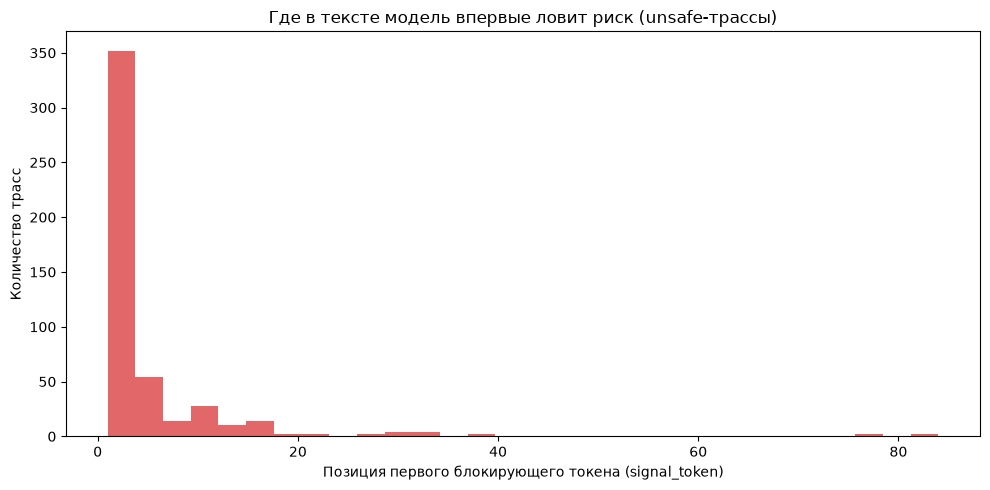

In [20]:
signal_data = run.results[
    (run.results["ground_truth_label"] == "unsafe")
    & (run.results["mode"] == "token")
    & (run.results["signal_token"].notna())
]

plt.figure(figsize=(10, 5))
plt.hist(signal_data["signal_token"], bins=30, color="tab:red", alpha=0.7)
plt.xlabel("Позиция первого блокирующего токена (signal_token)")
plt.ylabel("Количество трасс")
plt.title("Где в тексте модель впервые ловит риск (unsafe-трассы)")
plt.tight_layout()
plt.show()

> **Ограничение вычислительных метрик:** `checks_mean` — число решений буфера о показе
> или блокировке, а не число запусков Qwen3Guard. В текущем конвейере Qwen3Guard
> обрабатывает каждый токен один раз для всех режимов. `guard_time_ms` суммирует
> токенные задержки до симулируемого вмешательства и также не является независимо
> измеренным временем шести режимов. Поэтому прежний график нельзя было
> интерпретировать как сравнение вычислительной стоимости, и он удалён.

### Почему задержка чанка не равна его размеру

Разность `intervention_token - signal_token` показывает, сколько новых токенов система сгенерировала после сигнала Qwen3Guard, прежде чем режим разрешил вмешаться. Для отдельной трассы чанк размера `k` добавляет от 0 до `k - 1` токенов: сигнал может появиться в любой позиции внутри чанка, а последний чанк может быть неполным. Поэтому средние значения не обязаны равняться 8, 16 или 32. Это задержка вмешательства в токенах, а не время ожидания в миллисекундах. Точные средние уже приведены в компактной таблице и на графике выше.

## 11. Выводы

**Качество классификации.** FNR = 1.6% (4 из 250 unsafe пропущены, одинаково для
обеих политик), FPR = 13.2% (strict) / 14.0% (conservative). Разница между политиками
небольшая, но не нулевая: conservative блокирует на 2 safe-трассы больше, при этом
не спасает ни одной из 4 упущенных unsafe — то есть метка Controversial здесь влияет
только на over-blocking, а не на recall.

**Буферизация не влияет на факт блокировки** (это решает один и тот же токенный
прогон модели), но влияет на момент вмешательства: его верхняя оценка растёт от
`token` (~4,7 токена) до `full_buffered` (~101), а формальная leakage
падает в обратную сторону (4.5 → 0.84). Это не значит, что full_buffered
безопаснее — медиана leakage у него равна 0, то есть вне четырёх пропущенных
трасс частичной утечки нет вообще; всё среднее значение (0.84) — это цена
именно этих 4 ошибок классификатора, а не свойство самого режима.

Эти ~4,7 токена для `token` — не ожидание одного токена в интерфейсе. После сигнала
режим вмешивается сразу; число отражает позицию появления сигнала относительно
крайне консервативной нижней границы `L = 0`. Чанковые режимы дополнительно ждут
конца текущего скрытого чанка, зато не показывают пользователю токены из него.

Вывод: `token` и `full_buffered` — два разных контракта с пользователем: немедленная
потоковая выдача против удержания всего ответа. Текущий эксперимент сравнивает их
буферизацию, но не подтверждает различие в вычислительной стоимости Qwen3Guard.